<a href="https://colab.research.google.com/github/YasminMSouza/projCienciasdeDados/blob/main/decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install dtreeviz
from sklearn.datasets import load_iris
from sklearn import tree
import graphviz
from sklearn.model_selection import cross_val_score
from sklearn.inspection import permutation_importance
import dtreeviz.trees
import pandas as pd
from sklearn import datasets
from matplotlib import pyplot as plt
import numpy as np

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.3/102.3 kB 3.2 MB/s eta 0:00:00


In [6]:
dataset = pd.read_excel("/content/base_bruta.xlsx")

/usr/local/lib/python3.13/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
/usr/local/lib/python3.13/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed


In [7]:
dataset.head()

,ID_Jogo,Nome_Jogo,Plataforma,Genero,Ano_Lancamento,Nota_Critica,Nota_Jogadores,Vendas_Milhoes,Origem_Dados
0,1,Arcane Arena Evolution 0001,Xbox Series X/S,Sports,2020,73.0,68.1,12.80,Dados sintéticos
1,2,Frozen Voyage Genesis 0002,PlayStation 4,Shooter,2019,88.2,74.3,6.02,Dados sintéticos
2,3,Solar Horizon Origins 0003,Xbox 360,Sports,2022,75.4,68.0,2.76,Dados sintéticos
3,4,Eternal Outpost Genesis 0004,Xbox One,Sports,2017,54.8,50.8,3.10,Dados sintéticos
4,5,Eternal Horizon Aftermath 0005,Nintendo 3DS,Horror,2018,92.4,95.3,10.73,Dados sintéticos


In [8]:
dataset.shape

(5000, 9)

In [22]:
X = dataset[['Ano_Lancamento', 'Nota_Critica', 'Nota_Jogadores']]
print("Features (X) head after restriction:")
display(X.head())

Features (X) head after restriction:


,Ano_Lancamento,Nota_Critica,Nota_Jogadores
0,2020,73.0,68.1
1,2019,88.2,74.3
2,2022,75.4,68.0
3,2017,54.8,50.8
4,2018,92.4,95.3


In [11]:
y = dataset['Vendas_Milhoes']
print("Target (y) head:")
display(y.head())

Target (y) head:


,Vendas_Milhoes
0,12.80
1,6.02
2,2.76
3,3.10
4,10.73


In [17]:
from sklearn.tree import DecisionTreeRegressor

# Initialize the Decision Tree Regressor model
model = DecisionTreeRegressor(random_state=42) # Using random_state for reproducibility
print("Decision Tree Regressor model initialized.")

Decision Tree Regressor model initialized.


In [23]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Identify categorical and numerical features after restriction
categorical_features = [] # No categorical features selected
numerical_features = ['Ano_Lancamento', 'Nota_Critica', 'Nota_Jogadores']

# Create a column transformer. If no categorical features, it will only pass through numerical ones.
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Keep numerical features as they are
)

# Apply transformations to X
X_processed = preprocessor.fit_transform(X)

print("Shape of processed features (X_processed) after restriction:")
print(X_processed.shape)
print("The number of features is now reduced.")

Shape of processed features (X_processed) after restriction:
(5000, 3)
The number of features is now reduced.


In [18]:
# Fit the Decision Tree Regressor model
model.fit(X_processed, y)

print("Decision Tree Regressor model trained successfully.")
print(f"Model feature importances: {model.feature_importances_}")

Decision Tree Regressor model trained successfully.
Model feature importances: [0.01116814 0.01561088 0.01263357 0.00630688 0.01578063 0.01757164
 0.01036524 0.01019518 0.01090752 0.01823465 0.02015201 0.01227664
 0.00987285 0.00924327 0.01491859 0.01341226 0.01536588 0.01137022
 0.01491928 0.01074894 0.0195242  0.01182923 0.0926347  0.40371552
 0.2112421 ]


In [21]:
### Avaliação do Modelo de Árvore de Decisão

Agora que o modelo foi treinado, podemos avaliar seu desempenho. Além do R², que nos dá uma ideia de quão bem o modelo se ajusta aos dados, podemos também inspecionar a importância das características para entender quais variáveis foram mais influentes nas previsões.

SyntaxError: invalid character '²' (U+00B2) (4259401659.py, line 3)

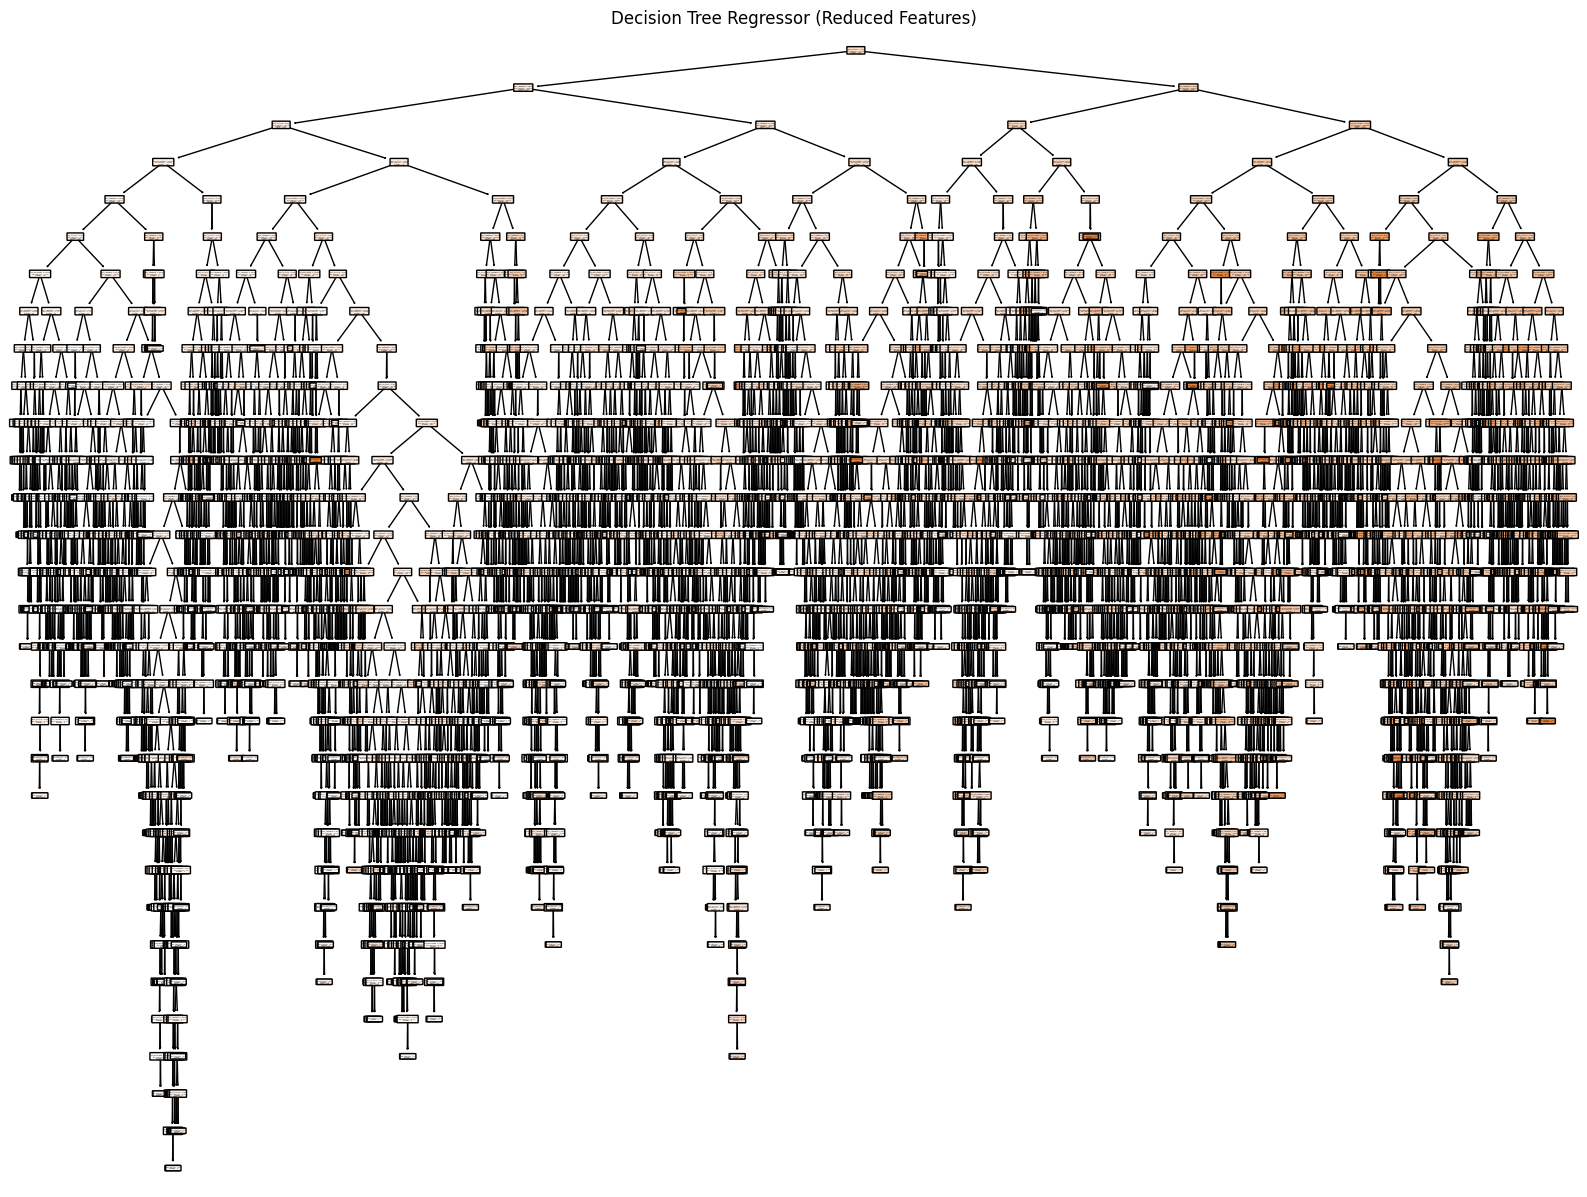

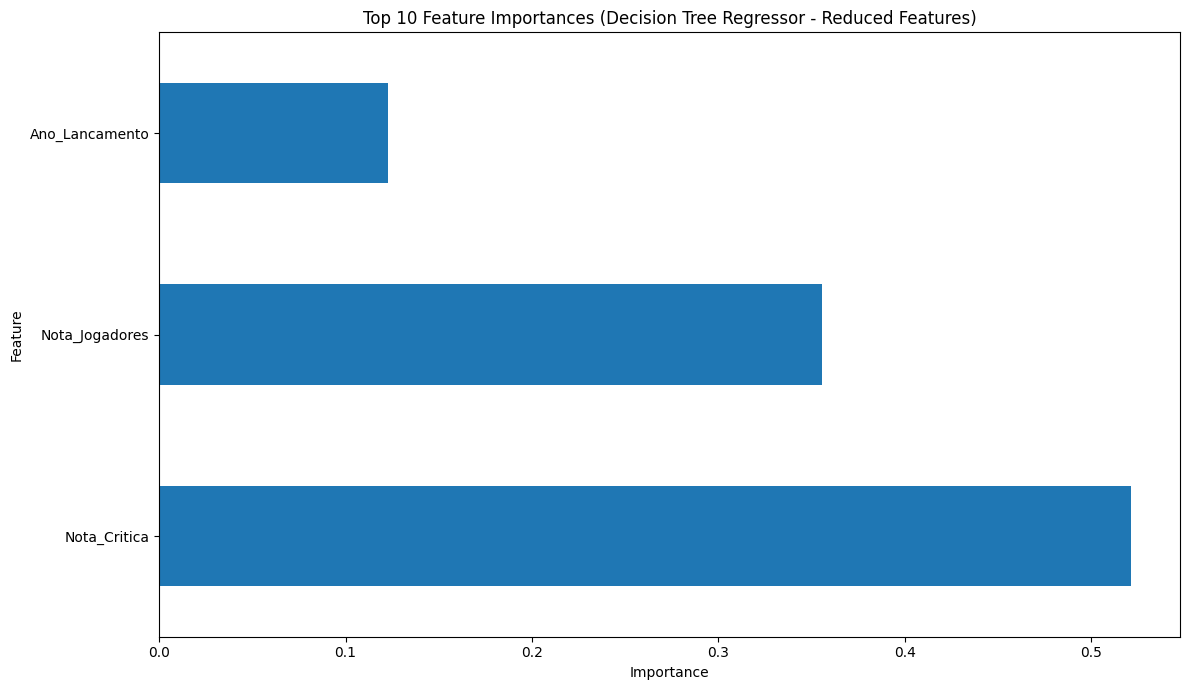

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt
import pandas as pd

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

# Re-train the model on the training data with a limited max_depth for better visualization
model_eval = DecisionTreeRegressor(random_state=42, max_depth=3) # Limiting depth to 3
model_eval.fit(X_train, y_train)

# Get feature names correctly for plotting
# Since there are no categorical features, all_feature_names is just numerical_features
all_feature_names = numerical_features

# --- Generate Decision Tree Plot ---
fig_tree = plt.figure(figsize=(20, 15)) # Adjust figure size for better visibility
plot_tree(model_eval, feature_names=all_feature_names, filled=True, rounded=True)
plt.title('Decision Tree Regressor (Reduced Features, Max Depth 3)') # Updated title
plt.savefig('decision_tree_reduced_max_depth_3.png') # New filename for clarity
plt.show()


# --- Generate Feature Importances Plot ---
plt.figure(figsize=(12, 7))
feature_importances = pd.Series(model_eval.feature_importances_, index=all_feature_names)
feature_importances.nlargest(10).plot(kind='barh')
plt.title('Top 10 Feature Importances (Decision Tree Regressor - Reduced Features)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.savefig('feature_importance_reduced_max_depth_3.png') # New filename for clarity
plt.show()

In [ ]:
print(X)

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

In [ ]:
clf = tree.DecisionTreeClassifier(criterion = 'entropy')

In [ ]:
clf = clf.fit(X, y)

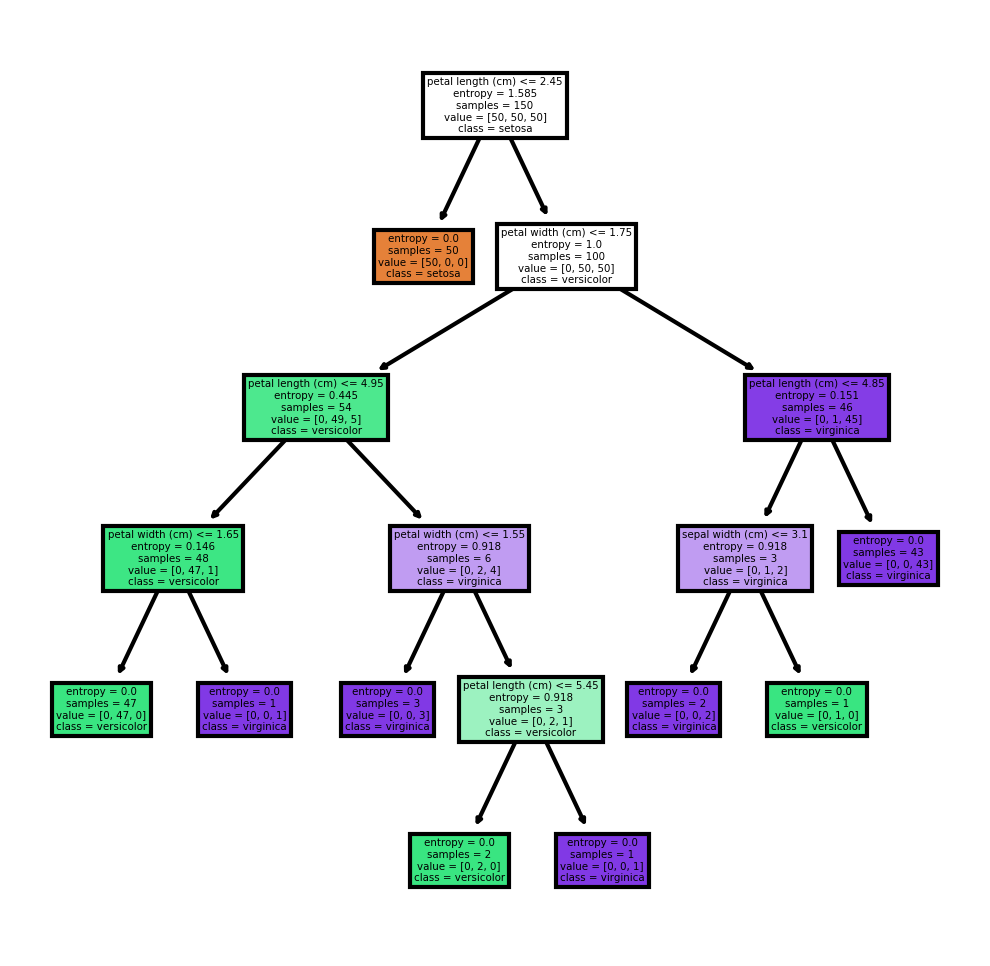

In [ ]:
fn=['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)']
cn=['setosa', 'versicolor', 'virginica']
fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (4,4), dpi=300)
tree.plot_tree(clf,
               feature_names = fn,
               class_names=cn,
               filled = True);
fig.savefig('imagename.png')

Text(0.5, 1.0, 'Feature Importance')

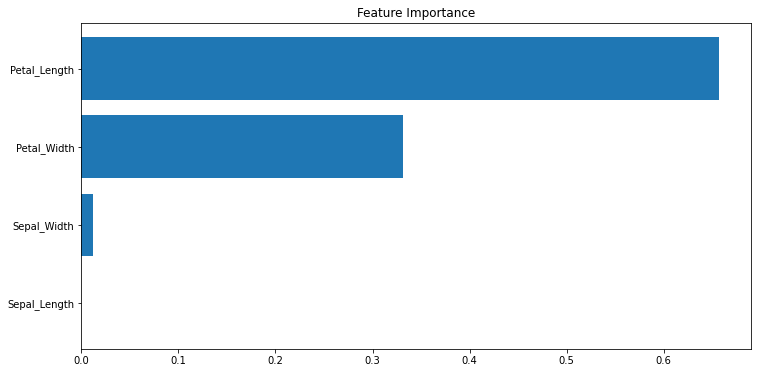

In [ ]:
feature_importance = clf.feature_importances_
sorted_idx = np.argsort(feature_importance)
fig = plt.figure(figsize=(12, 6))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), np.array(['Sepal_Length','Sepal_Width','Petal_Length','Petal_Width'])[sorted_idx])
plt.title('Feature Importance')

Referências

https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

https://www.rasgoml.com/feature-engineering-tutorials/how-to-generate-feature-importance-plots-from-scikit-learn

https://medium.com/chinmaygaikwad/feature-importance-and-visualization-of-tree-models-d491e8198b0a

